In [ ]:
import os 
import time 
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy.special import j0
import plotly.graph_objects as go
from iminuit.cost import LeastSquares
from scipy.integrate import fixed_quad

In [ ]:
# experimental data
save_folder = 'run7'
n_points = 10

lower_factor = 0.99
upper_factor = 2 - lower_factor

# Load experimental data
atlas_data = pd.read_csv('../../../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
totem_data = pd.read_csv('../../../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)

# Function to process data for each experiment
def process_data(data, energy_blocks):
    x_values = []
    y_values = []
    y_errors = []
    
    for start, end in energy_blocks:
        block = data.iloc[start:end] if end is not None else data.iloc[start:]
        x_values.append(block[0].values)
        y_values.append(block[1].values)
        y_errors.append(block[2].values)
    
    return x_values, y_values, y_errors

# Energy ranges for each experiment (7TeV, 8TeV, 13TeV)
atlas_blocks = [(0, 29), (29, 58), (58, None)]
totem_blocks = [(0, 65), (65, 118), (118, None)]

# Process data
x_atlas, y_atlas, yerr_atlas = process_data(atlas_data, atlas_blocks)

# Extract values by energy (index 0=7TeV, 1=8TeV, 2=13TeV)
x_7_atlas, y_7_atlas, yerr_7_atlas = x_atlas[0], y_atlas[0], yerr_atlas[0]
x_8_atlas, y_8_atlas, yerr_8_atlas = x_atlas[1], y_atlas[1], yerr_atlas[1]
x_13_atlas, y_13_atlas, yerr_13_atlas = x_atlas[2], y_atlas[2], yerr_atlas[2]

In [ ]:
# setting parameters
b_0 = (33 - 6) / (12 * np.pi)
Lambda = 0.284  # ΛQCD in GeV
gamma_1 = 0.084
gamma_2 = 2.36
rho = 4.0
s0 = 1.0
alpha_prime = 0.25



ensemble_parameters = {
    'atlas': {
        'log': {
            'epsilon': 0.0753,
            'mg': 0.356,
            'a1': 1.373,
            'a2': 2.50
        },
        'pl': {
            'epsilon': 0.0753,
            'mg': 0.421,
            'a1': 1.517,
            'a2': 2.05
        }
    },
    'totem': {
        'log': {
            'epsilon': 0.0892,
            'mg': 0.380,
            'a1': 1.491,
            'a2': 2.77
        },
        'pl':{
            'epsilon': 0.0892,
            'mg': 0.447,
            'a1': 1.689,
            'a2': 1.7
        }
    }
}

ensemble_atlas = 'atlas'  
ensemble_totem = 'totem'

log_model_type = 'log'
pl_model_type = 'pl'   

def get_parameters_with_variations(ensemble_parameters, ensemble_name, model_type, lower_factor=lower_factor, upper_factor=upper_factor):
    # Obtém os parâmetros iniciais
    initial_params = ensemble_parameters[ensemble_name][model_type]
    
    # Cria as variações
    initial_params_low = {k: v * lower_factor for k, v in initial_params.items()}
    initial_params_high = {k: v * upper_factor for k, v in initial_params.items()}
    
    return initial_params, initial_params_low, initial_params_high

# Get parameters for selected configuration
initial_params_pl_atlas = ensemble_parameters[ensemble_atlas][pl_model_type]

# Para Atlas
initial_params_pl_atlas, initial_params_low_pl_atlas, initial_params_high_pl_atlas = \
    get_parameters_with_variations(ensemble_parameters, ensemble_atlas, pl_model_type)




In [ ]:
# def model functions 
# --- Model functions, all using q2 notation --- 

def m2_log(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return mg ** 2 * ratio ** (-1 - gamma_1)


def m2_pl(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return (mg ** 4 / (q2 + mg ** 2)) * ratio ** (gamma_2 - 1)


def G_p(q2, a1, a2):
    return np.exp(-(a1 * q2 + a2 * q2 ** 2))


def alpha_D(q2, mg, m2_func):
    m2 = m2_func(q2, mg)
    return 1.0 / (b_0 * (q2 + m2) * np.log((q2 + 4 * m2) / (Lambda ** 2)))


# --- Amplitudes T1 and T2 rewritten with strict q2 notation ---

def T_1(k, q2, phi, mg, a1, a2, m2_func):
    q  = np.sqrt((q2))     # this is |q|
    k2 = k ** 2

    qk_cos = q * (k) * np.cos(phi)

    qk_plus_squared  = q2/4 + qk_cos + k2
    qk_minus_squared = q2/4 - qk_cos + k2

    alpha_D_plus  = alpha_D(qk_plus_squared,  mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)

    G0 = G_p(q2, a1, a2)

    return alpha_D_plus * alpha_D_minus * (G0 ** 2)


def T_2(k, q2, phi, mg, a1, a2, m2_func):
    q  = np.sqrt((q2))
    k2 = k ** 2

    qk_cos = q * (k) * np.cos(phi)

    qk_plus_squared  = q2/4 + qk_cos + k2
    qk_minus_squared = q2/4 - qk_cos + k2

    alpha_D_plus  = alpha_D(qk_plus_squared,  mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)

    factor = q2 + 9 * abs(k2 - q2/4)

    G0     = G_p(q2,    a1, a2)
    G_minus = G_p(factor, a1, a2)

    return alpha_D_plus * alpha_D_minus * G_minus * (2 * G0 - G_minus)

def sigma_tot(amp_value, s):
    return amp_value.imag / s * 0.389379323

def amp_calculation(diff_T, s, epsilon, t):
    alpha_pomeron = 1.0 + epsilon + alpha_prime * t
    regge_factor = (s**alpha_pomeron) * 1/(s0**(alpha_pomeron-1))
    return 1j * 8 * regge_factor * diff_T  

def differential_sigma(amp_value, s):
    amp_squared = amp_value * amp_value.conjugate()
    denominator = (16 * np.pi * s**2)
    return amp_squared / denominator * 0.389379323


In [ ]:
def full_int(mg, a1, a2, m2_func, q2_val, sqrt_s, n_points):
    q2_val = np.atleast_1d(q2_val)
    results = []

    for q2 in q2_val:                      # <- q2 is the correct variable
        def integrand(y, x, mg, a1, a2, m2_func, q2):
            k = sqrt_s * x
            phi = 2 * np.pi * y
            jacobian = 2 * np.pi * sqrt_s
            return k * (
                T_1(k, q2, phi, mg, a1, a2, m2_func)   # <-- FIXED: q instead of q_val
                - T_2(k, q2, phi, mg, a1, a2, m2_func)
            ) * jacobian

        def inner_integral(x):
            integral_real = fixed_quad(
                lambda y: np.real(integrand(y, x, mg, a1, a2, m2_func, q2)),
                0, 1, n=n_points
            )[0]
            integral_imag = fixed_quad(
                lambda y: np.imag(integrand(y, x, mg, a1, a2, m2_func, q2)),
                0, 1, n=n_points
            )[0]
            return integral_real + 1j * integral_imag

        integral_value = fixed_quad(inner_integral, 0, 1, n=n_points)[0]
        results.append(integral_value)

    return np.array(results) if len(results) > 1 else results[0]

In [ ]:
import numpy as np

def estimate_error_by_pilot(mg, a1, a2, m2_func, q2, sqrt_s,
                            n_target=5000,
                            n_list=(8, 16, 32, 64),
                            tiny_tol=1e-14,
                            eps_factor=1e3,
                            min_frac_of_maxdiff=1e-6):
    """
    Robust pilot estimator that avoids NaN/inf and returns a finite error.
    Strategy:
      - compute pilot integrals at n_list
      - if pilot differences are all tiny -> assume converged -> return machine-eps-based error
      - otherwise attempt power-law fit log(E)=log(C)-p*log(n) (in log-space)
      - compute predicted log-error safely; clip to reasonable bounds derived from pilot diffs
      - fallback to conservative difference-based error if fit is invalid

    Returns:
      I_target (complex), err_pred (float >=0), p_est (float or np.inf), diag (dict)
    """
    # --- compute pilot integrals ---
    n_list = tuple(n_list)
    pilot_vals = []
    for n in n_list:
        val = full_int(mg, a1, a2, m2_func, q2, sqrt_s, n_points=n)
        pilot_vals.append(val)
    pilot_vals = np.asarray(pilot_vals, dtype=complex)
    n_arr = np.asarray(n_list, dtype=float)

    I_ref = pilot_vals[-1]
    pilot_diffs = np.abs(np.diff(pilot_vals))
    pilot_errors = np.abs(pilot_vals - I_ref)  # errors relative to largest-n pilot

    # machine constants
    eps = np.finfo(float).eps
    abs_Iref = max(1.0, np.abs(I_ref))
    min_reasonable = eps_factor * eps * abs_Iref  # floor for predicted error

    # If pilot errors are all tiny -> assume converged
    if np.all(pilot_errors <= tiny_tol * abs_Iref):
        I_target = full_int(mg, a1, a2, m2_func, q2, sqrt_s, n_points=n_target)
        err_pred = float(min_reasonable)
        p_est = np.inf
        diag = {
            "mode": "converged_small_n",
            "pilot_vals": pilot_vals,
            "pilot_errors": pilot_errors,
            "pilot_diffs": pilot_diffs,
            "min_reasonable": min_reasonable,
        }
        return I_target, err_pred, p_est, diag

    # --- attempt log-linear fit on pilot_errors (avoid zeros) ---
    # replace exact zeros with a tiny positive number
    safe_errors = np.maximum(pilot_errors, 1e-300)
    X = np.log(n_arr)
    Y = np.log(safe_errors)

    # polyfit may be unstable; guard it
    try:
        slope, intercept = np.polyfit(X, Y, 1)  # Y = slope * X + intercept
        p_est = -slope
        logC = intercept
        fit_sane = np.isfinite(p_est) and p_est > 0 and np.isfinite(logC)
    except Exception:
        fit_sane = False
        p_est = np.nan
        logC = np.nan

    # compute predicted log-error = logC - p * log(n_target) safely
    if fit_sane:
        log_n_target = np.log(float(n_target))
        log_err_pred = logC - p_est * log_n_target

        # Avoid underflow/overflow: clip log_err_pred between bounds derived from data:
        # upper bound: log(max pilot diff) (can't be bigger than pilot differences)
        max_diff = np.max(pilot_diffs) if pilot_diffs.size > 0 else np.abs(I_ref)
        if max_diff <= 0:
            max_diff = abs_Iref
        log_upper = np.log(max_diff) + 0.0  # allow same order as largest observed diff

        # lower bound: log(min_reasonable)
        log_lower = np.log(min_reasonable)

        # If log_err_pred is above upper, clamp to upper; if below lower, clamp to lower.
        # This avoids ridiculously small or NaN results.
        if not np.isfinite(log_err_pred):
            # fallback
            fit_sane = False
        else:
            log_err_pred_clipped = np.clip(log_err_pred, log_lower, log_upper)
            err_pred = float(np.exp(log_err_pred_clipped))
    else:
        err_pred = None  # mark fallback later

    # If fit was not sane or produced degenerate err_pred, fallback to conservative method
    if (not fit_sane) or (err_pred is None) or (not np.isfinite(err_pred)):
        # conservative estimate: max successive pilot difference (or magnitude*eps)
        diffs = np.abs(np.diff(pilot_vals))
        conservative_err = np.max(diffs) if diffs.size > 0 else eps * abs_Iref
        # ensure we are not returning sub-machine precision
        err_pred = float(max(conservative_err, min_reasonable))
        # try to set a reasonable p_est if we can: approximate from two largest pilots
        if pilot_errors[-2] > 0 and pilot_errors[-1] > 0:
            try:
                p_est = np.log(pilot_errors[-2] / pilot_errors[-1]) / np.log(n_arr[-1] / n_arr[-2])
            except Exception:
                p_est = np.nan
        else:
            p_est = np.nan
        mode = "fallback_conservative"
    else:
        mode = "fitted"

    # final compute of I_target (expensive single call)
    I_target = full_int(mg, a1, a2, m2_func, q2, sqrt_s, n_points=n_target)

    diag = {
        "mode": mode,
        "pilot_n": n_list,
        "pilot_vals": pilot_vals,
        "pilot_errors": pilot_errors,
        "pilot_diffs": pilot_diffs,
        "min_reasonable": min_reasonable,
        "fit_logC": float(logC) if np.isfinite(logC) else None,
        "fit_p": float(p_est) if np.isfinite(p_est) else None,
    }

    return I_target, float(err_pred), float(p_est) if np.isfinite(p_est) else p_est, diag


In [ ]:
import numpy as np

def auto_tune_integral(mg, a1, a2, m2_func, q2, sqrt_s,
                       n_sequence=(500, 1000, 2000, 5000, 8000),
                       tol_abs=1e-8,
                       tol_rel=1e-6,
                       max_n=None,
                       return_all=False):
    """
    Auto-tune n (number of quadrature points) for full_int by increasing n until
    convergence criterion is met.

    Parameters
    ----------
    mg, a1, a2, m2_func, q2, sqrt_s : passed to full_int
    n_sequence : tuple/list of ints
        Increasing sequence of n to try. Use values appropriate to your problem.
    tol_abs : float
        Absolute tolerance for |I(n) - I(prev)|.
    tol_rel : float
        Relative tolerance for |I(n) - I(prev)| / max(1, |I(n)|).
    max_n : int or None
        Hard cap on n. If provided, any n > max_n in n_sequence will be skipped.
    return_all : bool
        If True, returns (I_choice, err_est, n_used, diagnostics) where diagnostics
        contains arrays of tried n and computed values.

    Returns
    -------
    I_choice : complex
        Selected integral value (computed with chosen n)
    err_est : float
        Absolute error estimate = |I_chosen - I_previous| (or fallback)
    n_used : int
        n at which the iteration stopped (or last tried n)
    diagnostics : dict (only if return_all True)
    """
    n_sequence = tuple(int(n) for n in n_sequence)
    if max_n is not None:
        n_sequence = tuple(n for n in n_sequence if n <= max_n)
        if len(n_sequence) == 0:
            raise ValueError("max_n is smaller than all entries in n_sequence")

    tried_n = []
    tried_vals = []

    I_prev = None
    for n in n_sequence:
        tried_n.append(n)
        I_n = full_int(mg, a1, a2, m2_func, q2, sqrt_s, n_points=n)
        tried_vals.append(I_n)

        if I_prev is not None:
            diff = abs(I_n - I_prev)
            # choose relative denominator that avoids tiny denominator issues
            denom = max(1.0, abs(I_n))
            if (diff <= tol_abs) or (diff / denom <= tol_rel):
                # convergence reached
                err_est = float(diff)
                diagnostics = {
                    "mode": "converged",
                    "tried_n": np.array(tried_n),
                    "tried_vals": np.array(tried_vals, dtype=complex),
                    "tol_abs": tol_abs,
                    "tol_rel": tol_rel,
                }
                if return_all:
                    return I_n, err_est, n, diagnostics
                return I_n, err_est, n
        # prepare next iteration
        I_prev = I_n

    # If loop finishes without meeting tolerance, return last tried with conservative error
    I_last = tried_vals[-1]
    if len(tried_vals) >= 2:
        fallback_err = float(abs(tried_vals[-1] - tried_vals[-2]))
    else:
        # single evaluation only; estimate error using machine precision times magnitude
        fallback_err = float(np.finfo(float).eps * max(1.0, abs(I_last)))

    diagnostics = {
        "mode": "max_n_reached",
        "tried_n": np.array(tried_n),
        "tried_vals": np.array(tried_vals, dtype=complex),
        "fallback_err": fallback_err,
        "tol_abs": tol_abs,
        "tol_rel": tol_rel,
    }

    if return_all:
        return I_last, fallback_err, tried_n[-1], diagnostics
    return I_last, fallback_err, tried_n[-1]



In [ ]:

# Example: integrate the auto-tuner into your get_dif_sigma loop
diff_t_born = []

def get_dif_sigma(epsilon, mg, a1, a2, mg_model,
                  n_sequence=(500, 1000, 2000, 5000, 8000),
                  tol_abs=1e-8, tol_rel=1e-6, max_n=8000):
    """
    Evaluate differential sigma over q2 range using auto_tune_integral per q2.
    """
    sqrt_s = 7000
    scale = 1
    start_q2 = 0.006
    max_q2   = 0.204
    q2_step  = 0.001

    lst_q2 = []
    lst_dif_sigma = []

    q2 = start_q2
    while q2 <= max_q2:
        t = -q2

        # auto-tune n and compute integral
        I_val, err_est, n_used = auto_tune_integral(
            mg, a1, a2, mg_model, q2, sqrt_s,
            n_sequence=n_sequence,
            tol_abs=tol_abs,
            tol_rel=tol_rel,
            max_n=max_n,
            return_all=False
        )

        # optional: compute rough "p_est" from last two tried values if you want diagnostics
        # (only available if return_all=True and you inspect diagnostics)

        print(f"q2={q2} | Integral={I_val} | Err≈{err_est:.3e} | n_used={n_used}")

        diff_T = I_val
        diff_t_born.append(diff_T)

        s = sqrt_s**2
        amp_value = amp_calculation(diff_T, s, epsilon, t)
        dif_sigma = differential_sigma(amp_value, s) * scale

        lst_q2.append(q2)
        lst_dif_sigma.append(dif_sigma)

        q2 += q2_step

    return {sqrt_s: (lst_q2, lst_dif_sigma)}


In [ ]:

#for pl atlas
dif_sigma_pl_atlas = get_dif_sigma(
    ensemble_parameters["atlas"]["pl"]['epsilon'],
    ensemble_parameters["atlas"]["pl"]['mg'], 
    ensemble_parameters["atlas"]["pl"]['a1'],
    ensemble_parameters["atlas"]["pl"]['a2'],
    m2_pl
)

dif_sigma_pl_atlas_7_q2 = dif_sigma_pl_atlas[7000][0]
dif_sigma_pl_atlas_7_values = dif_sigma_pl_atlas[7000][1]


In [39]:


def add_differential_trace(fig, x, y, label, color='red', mg_model= 'log', legend=True, size = 4, width = 2):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        line=dict(color=color, width=width),
        marker=dict(size=size),
        name=f'{label}, {mg_model}',
        showlegend=legend,

    ))

def add_data_trace(fig, x, y, y_error, scale=1.0, color='black', size=4,
                           name=None, show_label=True, mode='markers'):
    fig.add_trace(go.Scatter(
        x=x,
        y=y * scale,
        mode=mode,
        marker=dict(color=color, size=size),
        error_y=dict(
            type='data',
            array=y_error * scale,
            visible=True
        ),
        name=name if show_label else None,
        showlegend=show_label
    ))

fig_atlas = go.Figure()


# for pl atlas
add_differential_trace(fig_atlas, dif_sigma_pl_atlas_7_q2, np.real(dif_sigma_pl_atlas_7_values),label='7 TeV', color='blue', mg_model='pl')

#data points
add_data_trace(fig_atlas, x_7_atlas, y_7_atlas, yerr_7_atlas, name='ATLAS 7 TeV', show_label=True, mode='markers')

# Atualiza layout
fig_atlas.update_layout(
    title='dσ/dt vs. |t| - Log and PL models in ATLAS',
    xaxis_title='|t| (GeV²)',
    yaxis_title='dσ/dt (mb/GeV²)',
    yaxis_type='log',
    legend_title='Mass Model',
    plot_bgcolor='white',
    hovermode='x unified'
)

fig_atlas.update_xaxes(gridcolor='lightgray')
fig_atlas.update_yaxes(gridcolor='lightgray')

# fig_atlas.show(renderer='browser')


In [ ]:
# # PLOT BORN SIGMA TOT =============================================================
# # 
# # =============================================================


data_sigma_tot_atlas = pd.read_csv(
    "../../../../../data/sigma_tot_2/ensemble_StRh_atlas.dat",
    delim_whitespace=True,
    header=None,
    nrows=70
)

x_sigma_tot_atlas = data_sigma_tot_atlas[0].to_numpy()
y_sigma_tot_atlas = data_sigma_tot_atlas[1].to_numpy()
y_error_sigma_tot_atlas = data_sigma_tot_atlas[2].to_numpy()

lst_born_amp = []

start_sqrt_s = 1
max_sqrt_s = 13010
step = 100

def add_total_trace(fig, x, y, color='red', label='', line_style='solid', legend=True, size = 3, width = 2):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        line=dict(color=color, width=width, dash=line_style),
        marker=dict(size=size),
        name = label, 
        showlegend=legend
    ))


In [ ]:
def get_sigma_tot(epsilon, mg, a1, a2, mg_model,
                  n_sequence=(500, 1000, 2000, 5000, 8000),
                  tol_abs=1e-8, tol_rel=1e-6, max_n=8000):

    lst_sigma_tot = []
    lst_sqrt_s = []

    sqrt_s = start_sqrt_s

    while sqrt_s <= max_sqrt_s:

        s = sqrt_s ** 2

        # ------------------------------------------------------------------
        # AUTO–TUNED integration (only change in the function)
        # ------------------------------------------------------------------
        integral_value, err_est, n_used = auto_tune_integral(
            mg, a1, a2, mg_model,
            q2=0.0,
            sqrt_s=sqrt_s,
            n_sequence=n_sequence,
            tol_abs=tol_abs,
            tol_rel=tol_rel,
            max_n=max_n,
            return_all=False
        )

        print(f"sqrt(s)={sqrt_s} | Integral={integral_value} | Err≈{err_est:.3e} | n_used={n_used}")

        born_amp = amp_calculation(integral_value, s, epsilon, 0)
        lst_born_amp.append(born_amp)

        lst_sigma_tot.append(
            sigma_tot(born_amp, s)
        )

        lst_sqrt_s.append(sqrt_s)
        sqrt_s += step

    return lst_sigma_tot, lst_sqrt_s

##-----------------------------------------------------------------------------------------------

sigma_tot_pl_atlas = get_sigma_tot(
    ensemble_parameters["atlas"]["pl"]['epsilon'],
    ensemble_parameters["atlas"]["pl"]['mg'], 
    ensemble_parameters["atlas"]["pl"]['a1'],
    ensemble_parameters["atlas"]["pl"]['a2'],
    m2_pl
)

sigma_tot_pl_atlas_values = sigma_tot_pl_atlas[0]
lst_sqrt_s = sigma_tot_pl_atlas[1]


In [ ]:



fig = go.Figure()

add_total_trace(fig, lst_sqrt_s, sigma_tot_pl_atlas_values, color='blue', label='PL Atlas', line_style='solid')

#-----------------------------------------------------------------------------------------------
#----

add_data_trace(fig, x_sigma_tot_atlas, y_sigma_tot_atlas, y_error_sigma_tot_atlas, name='ATLAS', show_label=True, mode='markers')

fig.update_layout(
    title = 'σ_tot vs. √s - Ensemble Atlas and Totem in Log and PL model',
    xaxis=dict(
        title='√s [GeV]',
        type='log',
        range=[np.log10(2000), np.log10(14000)],
    ),
    yaxis=dict(
        title='σ_tot [mb]',
        range=[80, 125]
    ),
    showlegend=True,
    legend=dict(
        title='Ensembles'
    ),
    plot_bgcolor='white',
    hovermode='x unified'
)
    
fig.update_xaxes(gridcolor='lightgray')
fig.update_yaxes(gridcolor='lightgray')

# fig.show(renderer="browser")

In [ ]:
import numpy as np
from scipy.special import j0

# lists for results
lst_chi = []
lst_amp_eik = []
lst_diff_sigma = []

# integration grids
lst_q_integration = np.linspace(0, 20, 1000)
lst_b_integration = np.linspace(0, 15, 1000)

# Riemann-step
dq = lst_q_integration[1] - lst_q_integration[0]
db = lst_b_integration[1] - lst_b_integration[0]

# midpoints
q_midpoints = lst_q_integration[:-1] + dq / 2
b_midpoints = lst_b_integration[:-1] + db / 2

sqrt_s = 7000
s = sqrt_s ** 2


eik_amp_sum = 0

for b_val in lst_b_integration:

    chi_sum = 0

    for q_val in q_midpoints:

        # physical variables
        q2_val = q_val**2
        t = -q2_val                           # t = -q^2

        # ------------------------------------------
        # FIX #1: full_int must receive q, not q^2
        # ------------------------------------------
        integral_value, err_est, n_used = auto_tune_integral(
            ensemble_parameters["atlas"]["pl"]['mg'], 
            ensemble_parameters["atlas"]["pl"]['a1'],
            ensemble_parameters["atlas"]["pl"]['a2'],
            m2_pl,
            q2=q2_val,
            sqrt_s=sqrt_s,
            n_sequence=(500, 1000, 2000, 5000, 8000),
            tol_abs=1e-8,
            tol_rel=1e-6,
            max_n=80000,
            return_all=False
        )


        # Born amplitude
        born_amp = amp_calculation(
            integral_value,
            s,
            ensemble_parameters["atlas"]["pl"]['epsilon'],
            t
        )

        # χ(b) integrand
        chi_val = (1/s) * q_val * j0(b_val * q_val) * born_amp

        chi_sum += chi_val * dq  # Riemann midpoint sum

    # print(chi_sum)
    factor = 1 - np.exp(1j * chi_sum)
    eik_amp_value = (1j * s) * b_val * j0(b_val * np.sqrt(0.006)) * factor
    eik_amp_sum += eik_amp_value * db  

    print(b_val)


    lst_chi.append(chi_sum)
diff_sigma_val = (np.pi / (s**2)) * (eik_amp_sum * eik_amp_sum.conjugate()) * 0.39
print(diff_sigma_val)

In [ ]:
import numpy as np
from scipy.special import j0
lst_q0 = np.linspace(0.006, 0.205, 100)

for q0 in lst_q0:
        
    # ---------------------------
    # Parameters you can tune
    # ---------------------------
    N_q_orig = 1000         # original q grid size (for reference)
    N_b_orig = 1000         # original b grid size (for reference)

    N_q = 200               # reduced q grid for Born amplitude sampling (tune this: 120-400)
    N_b = 1000              # keep b resolution if you want (vectorization handles it)
    q_max = 20.0            # same as before
    b_max = 15.0            # same as before

    # auto_tune_integral parameters (reuse your defaults)
    n_sequence = (500, 1000, 2000, 5000, 8000)
    tol_abs = 1e-8
    tol_rel = 1e-6
    max_n = 8000

    # ---------------------------
    # Build grids (coarse q grid for Born amplitudes)
    # ---------------------------
    # Use midpoints for q sampling to be consistent with your Riemann approach
    lst_q_integration = np.linspace(0.0, q_max, N_q + 1)         # edges
    dq = lst_q_integration[1] - lst_q_integration[0]
    q_midpoints = lst_q_integration[:-1] + dq / 2.0              # length N_q

    lst_b_integration = np.linspace(0.0, b_max, N_b + 1)         # edges for b if you like
    db = lst_b_integration[1] - lst_b_integration[0]
    b_midpoints = lst_b_integration[:-1] + db / 2.0              # length N_b

    # physics constants
    sqrt_s = 7000.0
    s = sqrt_s ** 2

    # ---------------------------
    # 1) Compute Born amplitude B(q) on the reduced q_midpoints grid
    #    This is the only place we still call auto_tune_integral per q.
    # ---------------------------
    # Choose which ensemble and model (example: atlas pl)
    mg_atlas = ensemble_parameters["atlas"]["pl"]["mg"]
    a1_atlas = ensemble_parameters["atlas"]["pl"]["a1"]
    a2_atlas = ensemble_parameters["atlas"]["pl"]["a2"]
    epsilon_atlas = ensemble_parameters["atlas"]["pl"]["epsilon"]

    # Preallocate arrays
    B_q = np.empty(len(q_midpoints), dtype=complex)
    B_q_err = np.empty(len(q_midpoints), dtype=float)
    B_q_nused = np.empty(len(q_midpoints), dtype=int)

    # Evaluate Born amplitude for each q (coarse sampling)
    # You can parallelize this externally if needed (joblib, multiprocessing), but here we keep it simple.
    for i, q_val in enumerate(q_midpoints):
        q2_val = q_val ** 2
        # auto-tune integral to get the Born "diff_T" (same as earlier)
        I_val, err_est, n_used = auto_tune_integral(
            mg_atlas, a1_atlas, a2_atlas, m2_pl,
            q2=q2_val,
            sqrt_s=sqrt_s,
            n_sequence=n_sequence,
            tol_abs=tol_abs,
            tol_rel=tol_rel,
            max_n=max_n,
            return_all=False
        )
        B_q[i] = amp_calculation(I_val, s, epsilon_atlas, t=-q2_val)  # B(q) ≡ born_amp
        B_q_err[i] = err_est
        B_q_nused[i] = n_used

    # Optional: print simple diagnostics
    print("Computed B(q) on reduced grid: N_q =", len(q_midpoints))
    print("n_used stats: min, median, max =", np.min(B_q_nused), np.median(B_q_nused), np.max(B_q_nused))
    print("Typical error estimate (median) =", np.median(B_q_err))

    # ---------------------------
    # 2) Vectorized Hankel-like transform to obtain chi(b) for all b
    #    chi(b) = (1/s) * ∫_0^∞ q * J0(b q) * B(q) dq
    #    We approximate integral with np.trapz over q_midpoints.
    # ---------------------------
    # Build matrix of b*q for J0; shape (N_b, N_q)
    B_q_vals = B_q  # length N_q
    q_array = q_midpoints  # length N_q
    b_array = b_midpoints  # length N_b

    # Compute J0 argument matrix in a vectorized outer-product way
    #         shape (N_b, N_q)
    # Use broadcasting: (N_b,1) * (1,N_q)
    arg = np.outer(b_array, q_array)   # b_i * q_j

    # Evaluate J0 matrix
    J0_mat = j0(arg)                    # shape (N_b, N_q) -- in C, fast

    # Compute integrand matrix: q_j * J0(b_i q_j) * B(q_j)
    # Note: B_q is complex; integrand is complex
    integrand = (q_array * B_q_vals)[None, :] * J0_mat  # shape (N_b, N_q), dtype=complex

    # Integrate along q-axis with the trapezoidal rule (vectorized)
    # np.trapz integrates along axis=1 producing length-N_b array
    chi_b = (1.0 / s) * np.trapz(integrand, x=q_array, axis=1)   # shape (N_b,), complex

    # Store chi list if you need it
    lst_chi = chi_b.tolist()

    # ---------------------------
    # 3) Build eikonal amplitude vectorized over b, then integrate over b
    #    eikonal amplitude A_eik = i*s ∫ b J0(b*q0) [1 - exp(i χ(b))] db
    #    You used q0 = sqrt(0.006) in your original code; keep that
    # ---------------------------
  

    # factor = [1 - exp(i * chi(b))]
    factor = 1.0 - np.exp(1j * chi_b)   # shape (N_b,), complex

    # eik_amp integrand: (i*s) * b * J0(b*q0) * factor
    eik_integrand = (1j * s) * b_array * j0(b_array * np.sqrt(q0)) * factor  # shape (N_b,)

    # integrate over b with trapezoidal rule (vectorized)
    eik_amp = np.trapz(eik_integrand, x=b_array)   # complex scalar

    # differential sigma from eik_amp (same formula you had)
    diff_sigma_val = (np.pi / (s**2)) * (eik_amp * eik_amp.conjugate()) * 0.39

    print("diff_sigma_val =", diff_sigma_val)


In [40]:
import numpy as np
from scipy.special import j0

# lists for results
lst_chi = []
lst_amp_eik = []
lst_diff_sigma = []

# integration grids
lst_q_integration = np.linspace(0, 20, 1000)
lst_b_integration = np.linspace(0, 15, 1000)
lst_q2_exp = np.linspace(0.006, 0.205, 100)

# Riemann-step
dq = lst_q_integration[1] - lst_q_integration[0]
db = lst_b_integration[1] - lst_b_integration[0]

# midpoints
q_midpoints = lst_q_integration[:-1] + dq / 2
b_midpoints = lst_b_integration[:-1] + db / 2

sqrt_s = 7000
s = sqrt_s ** 2

# Precompute q² values and j0(b*q) for all b and q
q2_midpoints = q_midpoints**2
t_values = -q2_midpoints

# Create meshgrid for vectorization
B, Q = np.meshgrid(lst_b_integration, q_midpoints, indexing='ij')
# Precompute j0(b*q) for all b,q pairs
j0_bq = j0(B * Q)

for q2_exp in lst_q2_exp:
    # Calculate chi_sum for all b values at once
    chi_sum = np.zeros(len(lst_b_integration), dtype=complex)
    
    # We need to compute integral and Born amplitude for each q value
    for idx, q_val in enumerate(q_midpoints):
        # physical variables
        q2_val = q2_midpoints[idx]
        t = -q2_val
        
        # Integral computation (this part can't be vectorized due to function calls)
        integral_value, err_est, n_used = auto_tune_integral(
            ensemble_parameters["atlas"]["pl"]['mg'], 
            ensemble_parameters["atlas"]["pl"]['a1'],
            ensemble_parameters["atlas"]["pl"]['a2'],
            m2_pl,
            q2=q2_val,
            sqrt_s=sqrt_s,
            n_sequence=(500, 1000, 2000, 5000, 8000),
            tol_abs=1e-8,
            tol_rel=1e-6,
            max_n=80000,
            return_all=False
        )
        
        # Born amplitude
        born_amp = amp_calculation(
            integral_value,
            s,
            ensemble_parameters["atlas"]["pl"]['epsilon'],
            t
        )
        
        # Vectorized chi calculation for all b values at this q
        chi_sum += (1/s) * q_val * j0_bq[:, idx] * born_amp * dq
    
    # Print chi values for all b
    for b_idx, b_val in enumerate(lst_b_integration):
        print(f"b = {b_val:.2f}, χ(b) = {np.imag(chi_sum[b_idx]):.10f}")
    
    # Vectorized eik_amp calculation
    lst_chi.append(chi_sum)
    factor = 1 - np.exp(1j * chi_sum)
    j0_b_qexp = j0(lst_b_integration * np.sqrt(q2_exp))
    eik_amp_values = (1j * s) * lst_b_integration * j0_b_qexp * factor
    eik_amp_sum = np.sum(eik_amp_values * db)
    
    diff_sigma_val = (np.pi / (s**2)) * (eik_amp_sum * eik_amp_sum.conjugate()) * 0.39
    lst_diff_sigma.append(diff_sigma_val)
    print(f"q2_exp = {q2_exp:.4f}, diff_sigma = {diff_sigma_val}")

b = 0.00, χ(b) = 12.5016916174
b = 0.02, χ(b) = 12.5016204829
b = 0.03, χ(b) = 12.5014070818
b = 0.05, χ(b) = 12.5010514211
b = 0.06, χ(b) = 12.5005535125
b = 0.08, χ(b) = 12.4999133725
b = 0.09, χ(b) = 12.4991310221
b = 0.11, χ(b) = 12.4982064872
b = 0.12, χ(b) = 12.4971397982
b = 0.14, χ(b) = 12.4959309903
b = 0.15, χ(b) = 12.4945801034
b = 0.17, χ(b) = 12.4930871819
b = 0.18, χ(b) = 12.4914522751
b = 0.20, χ(b) = 12.4896754369
b = 0.21, χ(b) = 12.4877567259
b = 0.23, χ(b) = 12.4856962052
b = 0.24, χ(b) = 12.4834939427
b = 0.26, χ(b) = 12.4811500111
b = 0.27, χ(b) = 12.4786644875
b = 0.29, χ(b) = 12.4760374538
b = 0.30, χ(b) = 12.4732689966
b = 0.32, χ(b) = 12.4703592069
b = 0.33, χ(b) = 12.4673081807
b = 0.35, χ(b) = 12.4641160184
b = 0.36, χ(b) = 12.4607828250
b = 0.38, χ(b) = 12.4573087102
b = 0.39, χ(b) = 12.4536937885
b = 0.41, χ(b) = 12.4499381787
b = 0.42, χ(b) = 12.4460420044
b = 0.44, χ(b) = 12.4420053937
b = 0.45, χ(b) = 12.4378284795
b = 0.47, χ(b) = 12.4335113989
b = 0.48

KeyboardInterrupt: 

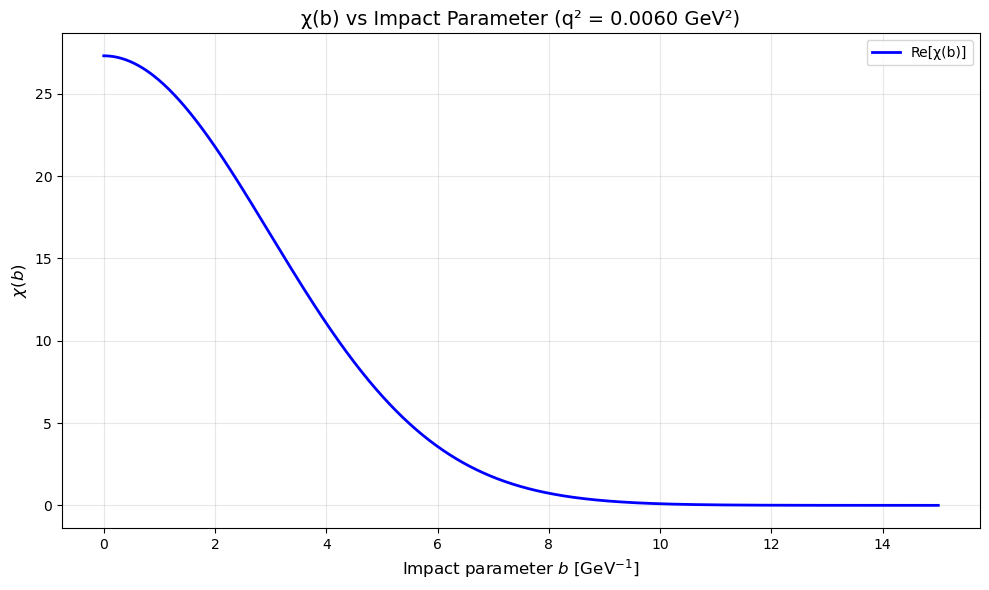

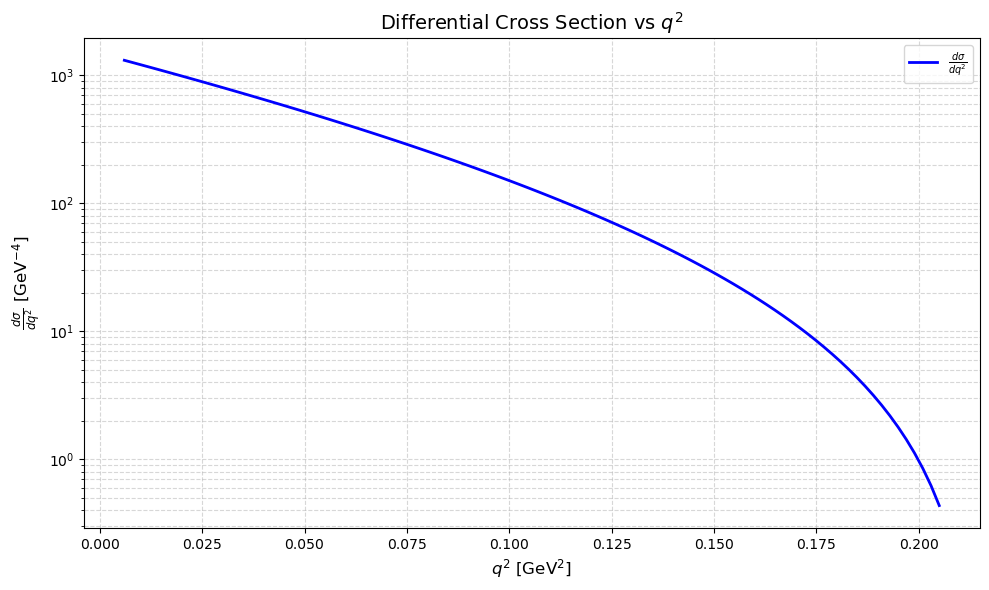

In [38]:
# After the loop, add this plotting code:
# Plot χ(b) for the first q2_exp value (or you can choose a specific one)
plt.figure(figsize=(10, 6))

# Plot both real and imaginary parts
if len(lst_chi) > 0:
    # Choose which q2_exp value to plot (first one by default)
    chi_to_plot = lst_chi[0]  # Change index to plot different q2_exp values
    
    plt.plot(lst_b_integration, np.imag(chi_to_plot), 'b-', linewidth=2, label='Re[χ(b)]')
    
    plt.xlabel(r'Impact parameter $b$ [GeV$^{-1}$]', fontsize=12)
    plt.ylabel(r'$\chi(b)$', fontsize=12)
    plt.title(f'χ(b) vs Impact Parameter (q² = {lst_q2_exp[0]:.4f} GeV²)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
# After the loop, add this plotting code:
import matplotlib.pyplot as plt
# Convert results to numpy array for plotting
diff_sigma_array = np.array(lst_diff_sigma)

# Plot differential cross section vs q2_exp
plt.figure(figsize=(10, 6))
plt.plot(lst_q2_exp, diff_sigma_array, 'b-', linewidth=2, label=r'$\frac{d\sigma}{dq^2}$')
plt.yscale('log')  # Set y-axis to log scale
plt.xlabel(r'$q^2$ [GeV$^2$]', fontsize=12)
plt.ylabel(r'$\frac{d\sigma}{dq^2}$ [GeV$^{-4}$]', fontsize=12)
plt.title('Differential Cross Section vs $q^2$', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()